<h1><center> First GAN on MNIST Digits Dataset

In [1]:
import torch
from torch import nn
from torch.utils.data import DataLoader


from torchvision.datasets import MNIST
from torchvision import transforms




torch.manual_seed(0)



In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
# Load the dataset
batch_size = 128
dataloader = DataLoader(
                        MNIST('.', download= True, transform= transforms.ToTensor()), 
                        batch_size= batch_size,
                        shuffle= True)

### Generator

<pre>
Make a single layer/block for the generator's neural network.

Each block include:
    - Linear transformation
    - Batch normalization
    - Non linear activation function (ReLU)

In [4]:
def get_generator_block(input_dim, output_dim):
    return nn.Sequential(
        nn.Linear(input_dim, output_dim),
        nn.BatchNorm1d(output_dim),
        nn.ReLU(inplace= True)
    )

<pre>Now we build the generator class.
It will take 3 values:
    - The noise vector dimension
    - The image dimension
    - The initial hidden dimension

Using these values, the generator will build a NN with 5 layers.

Beginning with the noise vector, the generator will apply non-linear transformations via the block function 
until the tensor is mapped to the size of the image to be outputted (the same size as the real 
images from MNIST). 

The final layer does not need a normalization or activation function, but does need to be scaled with 
a sigmoid function.

Finally, the forward pass function  takes in a noise vector and generates an image of the output dimension 
using the neural network.



In [5]:
class Generator(nn.Module):
    def __init__(self, z_dim= 10, im_dim= 784, hidden_dim= 128):
        super().__init__()
        self.gen = nn.Sequential(
            get_generator_block(z_dim, hidden_dim),
            get_generator_block(hidden_dim, hidden_dim * 2),
            get_generator_block(hidden_dim * 2, hidden_dim * 4),
            get_generator_block(hidden_dim * 4, hidden_dim * 8),
            nn.Linear(hidden_dim * 8, im_dim),
            nn.Sigmoid() # Génère des pixels entre 0 et 1 Explication en bas !!!!!
        )
        
    
    
    def forward(self, noise):
        return self.gen(noise)
    
    

Explication:

<p>

* <i>MNIST('.', download=True, transform=transforms.ToTensor())</i>: Cette ligne de code prend les images brutes de MNIST (dont les pixels vont de 0 à 255) et les convertit automatiquement en valeurs comprises strictement entre 0.0 et 1.0.

* Notre générateur doit générer des images dont les pixels sont entre 0.0 et 1.0 c'est pourquoi on utilise sigmoid.

* La fonction mathématique Sigmoid écrase n'importe quelle valeur d'entrée pour renvoyer une valeur comprise entre 0 et 1.</p>

#

#

#

<pre> Create the noise vectors by sampling random numbers from the normal distribution.


In [6]:
def get_noise(n_samples, z_dim, device= device):
    return torch.randn(n_samples, z_dim, device= device)

### Descriminator:

<pre> A discriminator neural network layer contains:
    - Linear transformation 
    - Non linear activation function LeakyReLU activation with negative slope of 0.2 

In [7]:
def get_discriminator_block(input_dim, output_dim):
    return nn.Sequential(
        nn.Linear(input_dim, output_dim),
        nn.LeakyReLU(negative_slope= 0.2)
        
    )

<pre>Now we build the discriminator class.
It will take 2 values:
    - The image dimension
    - The hidden dimension

Using these values, the generator will build a NN with 4 layers.

It starts with the image tensor and transform it until it returns a single number (1-dimension tensor) output. 

This output classifies whether an image is fake or real. 

! Note that you do not need a sigmoid after the output layer since it is included in the loss function. 





In [8]:
class Discriminator(nn.Module):
    def __init__(self, im_dim = 784, hidden_dim = 128):
        super().__init__()
        
        self.disc = nn.Sequential(
            get_discriminator_block(im_dim, hidden_dim * 4),
            get_discriminator_block(hidden_dim * 4, hidden_dim * 2),
            get_discriminator_block(hidden_dim * 2, hidden_dim),
            nn.Linear(hidden_dim, 1)
            # pas de nn.Sigmoid() car on va utiliser nn.BCEWithLogitsLoss qui contient déjà sigmoid
        )
        
        
        
    def forward(self, image):
        return self.disc(image)

<img src="gan_mnist.png">

### Initialisation des paramétres, du générateur et du descriminateur

In [9]:
criterion = nn.BCEWithLogitsLoss()

n_epochs = 10
z_dim = 64
batch_size = 128
lr = 0.00001





In [10]:
# initialiser le generator et le descriminator

gen = Generator(z_dim).to(device)

disc = Discriminator().to(device)

In [11]:
# optimizer for generator
gen_optim = torch.optim.Adam(gen.parameters(), lr= lr)


# optimizer for discriminator
disc_optim = torch.optim.Adam(disc.parameters(), lr= lr)

### Loss Function

Before training the GAN, we need to create functions to calculate the discriminator's loss and the generator's loss. 

Since the generator is needed when calculating the discriminator's loss, you will need to call .detach() on the generator result to ensure that only the discriminator is updated!


In [12]:
def get_disc_loss(gen, disc, criterion, real, num_images, z_dim, device):
    
    # 1- Create noise vectors and generate a batch (num_images) of fake images. 
    z_noise = get_noise(num_images, z_dim, device= device)
    fake_images = gen(z_noise)
    
    # 2- get the desciminator's prediction of the fake image and calculate the loss
    pred_disc_fake = disc(fake_images.detach())
    disc_loss_fake = criterion(pred_disc_fake, torch.zeros_like(pred_disc_fake))
    
    
    # 3- Get the discriminator's prediction of the real image and calculate the loss.
    pred_disc_real = disc(real)
    disc_loss_real = criterion(pred_disc_real, torch.ones_like(pred_disc_real)) 
    
    # 4- Calculate the discriminator's loss by averaging the real and fake loss and set it to disc_loss.
    disc_loss = (disc_loss_fake + disc_loss_real)/2
    
    return disc_loss

In [13]:
def get_gen_loss(gen, disc, criterion, num_images, z_dim, device):
    # 1- Create noise vectors and generate a batch of fake images. device argument
    z_noise = get_noise(num_images, z_dim, device= device)
    fake_images = gen(z_noise)
    
    
    # 2- Get the discriminator's prediction of the fake image.
    disc_pred_fake = disc(fake_images)
    
    # 3-  Calculate the generator's loss. Remember the generator wants the discriminator to think that its fake images are real
    gen_loss = criterion(disc_pred_fake, torch.ones_like(disc_pred_fake))
    return gen_loss

### ENTRAINEMENT

In [ ]:
# Listes pour sauvegarder les pertes et suivre l'évolution
disc_losses = []
gen_losses = []



# On a 60 000 images dans MNIST
# Un batch size de 128, c'est à dire le nombre de paquets dans une seule boucle est de 468
# Pour faire une seule époch , la boucle interne tourne 468 fois!
# Avec step on veut afficher un message tous les 500 paquets pour voir ce qui se passe en direct à l'intérieur de l'époque.
display_step = 500  # Afficher l'état tous les 500 batches
step = 0

print("Démarrage de l'entraînement...")

for epoch in range(n_epochs):
    # Pour chaque batch d'images dans notre dataloader
    for real, _ in dataloader:
        # 1. Obtenir le nombre d'images dans le batch actuel
        curr_batch_size = len(real)
        
        # 2. Aplatir les vraies images de [128, 1, 28, 28] à [128, 784] 
        # et les envoyer sur le bon périphérique (CPU ou GPU)
        real = real.view(curr_batch_size, -1).to(device)

        ### --- PHASE 1 : ENTRAÎNER LE DISCRIMINATEUR --- ###
        # On remet à zéro les gradients du discriminateur
        disc_optim.zero_grad()
        
        # On calcule la perte du discriminateur avec TA fonction
        disc_loss = get_disc_loss(gen, disc, criterion, real, curr_batch_size, z_dim, device)
        
        # Backpropagation : on calcule les gradients pour le discriminateur
        disc_loss.backward(retain_graph=True) 
        # (retain_graph=True est nécessaire car on va réutiliser le générateur juste après)
        
        # Mise à jour des poids du discriminateur
        disc_optim.step()

        ### --- PHASE 2 : ENTRAÎNER LE GÉNÉRATEUR --- ###
        # On remet à zéro les gradients du générateur
        gen_optim.zero_grad()
        
        # On calcule la perte du générateur avec TA fonction
        gen_loss = get_gen_loss(gen, disc, criterion, curr_batch_size, z_dim, device)
        
        # Backpropagation : on calcule les gradients pour le générateur
        gen_loss.backward()
        
        # Mise à jour des poids du générateur
        gen_optim.step()

        # --- Sauvegarde et affichage des statistiques ---
        disc_losses.append(disc_loss.item())
        gen_losses.append(gen_loss.item())

        if step % display_step == 0:
            print(f"Époque [{epoch+1}/{n_epochs}] | Step {step} | Loss D: {disc_loss.item():.4f} | Loss G: {gen_loss.item():.4f}")
        
        step += 1

print("Entraînement terminé !")

Démarrage de l'entraînement...
Époque [1/10] | Step 0 | Loss D: 0.6920 | Loss G: 0.6854
Époque [2/10] | Step 500 | Loss D: 0.3408 | Loss G: 1.6422
Époque [3/10] | Step 1000 | Loss D: 0.2161 | Loss G: 1.8377
Époque [4/10] | Step 1500 | Loss D: 0.1495 | Loss G: 1.9751
Époque [5/10] | Step 2000 | Loss D: 0.2171 | Loss G: 1.7118
Époque [6/10] | Step 2500 | Loss D: 0.1716 | Loss G: 1.9621
Époque [7/10] | Step 3000 | Loss D: 0.1497 | Loss G: 2.1772
Époque [8/10] | Step 3500 | Loss D: 0.1331 | Loss G: 2.4256
Époque [9/10] | Step 4000 | Loss D: 0.1107 | Loss G: 3.2132
Époque [10/10] | Step 4500 | Loss D: 0.0973 | Loss G: 3.2309
Entraînement terminé !


In [30]:
# mon code d'entrainement
# liste pour enregistrer loss pour générateur et descriminateur


gen_losses = []
disc_losses = []


epochs = 10

for epoch in range(epochs):
    for real, _ in dataloader:
        
        num_images = len(real)
        
        # Entrainement du descriminateur
        disc.train() 
        
        real = real.view(num_images, -1)
        
        
        disc_loss = get_disc_loss(gen, disc, criterion, real, num_images, z_dim, device)
        disc_optim.zero_grad()
        disc_loss.backward(retain_graph= True)
        disc_optim.step()
        
        # Entrainement du générateur
        gen.train()
        
        gen_loss = get_gen_loss(gen, disc, criterion, num_images, z_dim, device)
        gen_optim.zero_grad()
        gen_loss.backward()
        gen_optim.step()
        
        
        # enregistrer les losses
        disc_losses.append(disc_loss)
        gen_losses.append(gen_loss.item())

    print(f"Epoch {epoch} | Loss G : {gen_loss.item():.4f} | Loss D : {disc_loss.item():.4f}")

Epoch 0 | Loss G : 3.7384 | Loss D : 0.0835
Epoch 1 | Loss G : 3.7298 | Loss D : 0.0657
Epoch 2 | Loss G : 3.8784 | Loss D : 0.0561
Epoch 3 | Loss G : 4.1784 | Loss D : 0.0330
Epoch 4 | Loss G : 3.8968 | Loss D : 0.0590
Epoch 5 | Loss G : 3.6852 | Loss D : 0.0662
Epoch 6 | Loss G : 3.4248 | Loss D : 0.0407
Epoch 7 | Loss G : 3.8067 | Loss D : 0.0825
Epoch 8 | Loss G : 3.9082 | Loss D : 0.0547
Epoch 9 | Loss G : 4.1300 | Loss D : 0.0464


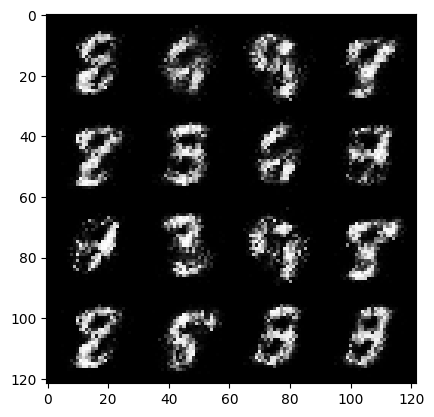

In [31]:
# afficher les images générées
import torchvision
import matplotlib.pyplot as plt

gen.eval()
with torch.no_grad():
    num_test_images = 16
    
    test_noise = get_noise(num_test_images, z_dim, device= device)
    
    generated_images = gen(test_noise)
    
    generated_images = generated_images.view(num_test_images, 1, 28, 28)
    
grid = torchvision.utils.make_grid(generated_images, nrow= 4)

plt.imshow(grid.permute(1, 2, 0).squeeze())
plt.show()

Le Générateur ne voit jamais les images réelles. Il est complètement "aveugle" à la réalité.

1- Le Générateur dessine un gribouillage au hasard et le donne au Discriminateur.

2- Le Discriminateur (qui lui, regarde les vraies images à chaque époch, à chaque étape) compare le gribouillage avec la réalité.

3- Le Discriminateur dit au Générateur : "C'est faux ! Et tu t'es trompé de telle intensité sur tel et tel pixel".

4- Le Générateur ajuste ses neurones uniquement en fonction de ce reproche.


